In [66]:
import os
from datetime import date, datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew
from scipy.signal import find_peaks

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

import ruptures as rpt

from pathlib import Path

## Feature Extraction

In [3]:
def statistical_features(arr):
    vmin = np.amin(arr)
    vmax = np.amax(arr)
    mean = np.mean(arr)
    std = np.std(arr)
    return vmin, vmax, mean, std

def shape_features(arr):
    skewness = skew(arr)
    kurt = kurtosis(arr)
    return skewness, kurt

In [12]:
# user = 'DF'

## Pre-processing

In [13]:
# import_path = f'{user}'
# export_path = f'{user}'

# rightEDAdatapath  = f'{import_path}/EDA.csv'
# rightHRdatapath   = f'{import_path}/HR.csv'
# rightTEMPdatapath = f'{import_path}/TEMP.csv'

In [14]:
# rightHRdatapath = np.loadtxt(rightHRdatapath, delimiter = ',')
# rightHRdatapath = np.repeat(rightHRdatapath, 4)
# np.savetxt('hr_new.csv', rightHRdatapath, delimiter = ',')

In [15]:
# edat =  pd.read_csv(f'{user}/EDA.csv',  header = 2,  names = ['EDA'])
# hrt =   pd.read_csv(f'hr_new.csv',      header = 12, names = ['HR'])
# # tempt = pd.read_csv(f'{user}/Temp.csv', header = 2,  names = ['TEMP'])
# gt =    pd.read_csv(f'{user}/EDA.csv',  nrows  = 1)

In [16]:
# reference_time = gt.iloc[0,0]
# min_len = min(len(edat), len(hrt), len(tempt))

# eda = edat.iloc[:min_len, 0]
# hrt = hrt.iloc[:min_len, 0]
# tempt = tempt.iloc[:min_len, 0]
# df_original = pd.concat([eda, hrt, tempt], axis = 1)

NameError: name 'tempt' is not defined

In [68]:
def round_time_and_interpulate(df):
    df['rounded_timestamp'] = (df['datetime'].dt.floor('s') +
                               (df['datetime'].dt.microsecond // 250000) * pd.Timedelta('250ms'))
    min_timestamp = df['rounded_timestamp'].min()
    max_timestamp = df['rounded_timestamp'].max()
    all_quarters = pd.date_range(start=min_timestamp, end=max_timestamp, freq='250ms')
    # Merge the new DataFrame with the result DataFrame to get heart rate per minute for every quarter of a second
    full_result_df = pd.DataFrame({'rounded_timestamp': all_quarters})
    full_result_df = full_result_df.merge(df, on='rounded_timestamp', how='left')
    # Interpolate the heart rate values to fill NaN values
    full_result_df['value'] = full_result_df['value'].interpolate()
    return full_result_df

user = "TRAIL003"
user_all_data_path = Path(user).joinpath("all_data.parquet")
if user_all_data_path.exists():
    all_data = pd.read_parquet(user_all_data_path, engine='fastparquet')
else:
    all_eda_df = pd.read_parquet(user + "/" + "all_eda_df" + ".parquet", engine='fastparquet')
    all_hr_df = pd.read_parquet(user + "/" + "all_hr_df" + ".parquet", engine='fastparquet')
    all_temp_df = pd.read_parquet(user + "/" + "all_temp_df" + ".parquet", engine='fastparquet')
    all_eda_df = round_time_and_interpulate(all_eda_df)
    all_temp_df = round_time_and_interpulate(all_temp_df)
    
    lean_eda = pd.DataFrame({'EDA': all_eda_df["value"].values}, index=all_eda_df["rounded_timestamp"].values)
    lean_hr= pd.DataFrame({'HR': all_hr_df["hr_per_minute"].values}, index=all_hr_df["rounded_timestamp"].values)
    lean_temp= pd.DataFrame({'temp': all_temp_df["value"].values}, index=all_temp_df["rounded_timestamp"].values)
    # dataframes = sorted([lean_eda, lean_hr, lean_temp], key=lambda x: x.size)
    # all_data = dataframes[0]
    # for i in range(1, len(dataframes)):
    #     all_data = pd.merge(all_data, dataframes[i], left_index=True, right_index=True, how='inner')
    all_data = pd.merge(lean_eda, lean_hr, left_index=True, right_index=True, how='inner')
    all_data = pd.merge(all_data, lean_temp, left_index=True, right_index=True, how='inner')
    all_data.to_parquet(user_all_data_path)

In [79]:
print(all_data.index[0], all_data.index[-1])
reference_time = all_data.index[0].timestamp()
print(reference_time)
start_time = pd.to_datetime("2025-04-05")
print(all_data.index[0].date, start_time.date())
data = all_data[(all_data.index.date == start_time.date())]
print(data.index[0], data.index[-1])
# partial_rows_num = 24*60*60*4
# data = all_data.dropna().head(partial_rows_num)

2025-04-02 21:20:33.500000 2025-04-28 21:17:39.500000
1743628833.5
<bound method Timestamp.date of Timestamp('2025-04-02 21:20:33.500000')> 2025-04-05
2025-04-05 00:00:00 2025-04-05 23:59:59.750000


In [80]:
# array = df_original.values
# data = pd.DataFrame(array)
# data.columns = ['EDA','HR','temp']

cols = [
    'EDA_Mean','EDA_Min','EDA_Max','EDA_Std', 'EDA_Kurtosis', 'EDA_Skew','EDA_Num_Peaks','EDA_Amphitude','EDA_Duration',
    'HR_Mean','HR_Min','HR_Max','HR_Std','HR_RMS','temp_Mean', 'temp_Min','temp_Max','temp_Std'
]
df_features = pd.DataFrame(columns=cols)

index = 0

for i in range(0,len(data['EDA']), 20):
    df_partial = data.iloc[i:i+40,]
    plen = len(df_partial['EDA'])
    
    if plen < 40:
        continue
    
    eda = df_partial['EDA'].values
    hr = df_partial['HR'].values
    temp = df_partial['temp'].values

    eda_min, eda_max, eda_mean, eda_std = statistical_features(eda)
    hr_min, hr_max, hr_mean, hr_std = statistical_features(hr)
    temp_min, temp_max, temp_mean, temp_std = statistical_features(temp)
    eda_skew, eda_kurtosis = shape_features(eda)
    
    hr_rms = np.sqrt(np.mean(np.square(np.ediff1d(hr))))
    temp_rms= np.sqrt(np.mean(np.square(np.ediff1d(temp))))

    peaks,properties = find_peaks(eda, width=5)
    num_Peaks = len(peaks)
    
    prominences = np.array(properties['prominences'])
    widths = np.array(properties['widths'])
    amphitude = np.sum(prominences)
    duration = np.sum(widths)

    df_features.loc[index] = [eda_mean, eda_min, eda_max, eda_std, eda_kurtosis, eda_skew, num_Peaks, amphitude, duration, hr_mean, hr_min, hr_max, hr_std,hr_rms, temp_mean, temp_min, temp_max, temp_std]
    index = index+1

In [81]:
cols = list(map(str, range(30, 0, -1)))
df_lag_features = pd.DataFrame(columns=cols)
df_lag_features = pd.concat([
    df_features['HR_Mean'].shift(10),  df_features['HR_Mean'].shift(9),    df_features['HR_Mean'].shift(8),
    df_features['HR_Mean'].shift(7),   df_features['HR_Mean'].shift(6),    df_features['HR_Mean'].shift(5),
    df_features['HR_Mean'].shift(4),   df_features['HR_Mean'].shift(3),    df_features['HR_Mean'].shift(2),
    df_features['HR_Mean'].shift(1),   df_features['temp_Mean'].shift(10), df_features['temp_Mean'].shift(9),
    df_features['temp_Mean'].shift(8), df_features['temp_Mean'].shift(7),  df_features['temp_Mean'].shift(6),
    df_features['temp_Mean'].shift(5), df_features['temp_Mean'].shift(4),  df_features['temp_Mean'].shift(3),
    df_features['temp_Mean'].shift(2), df_features['temp_Mean'].shift(1),  df_features['EDA_Mean'].shift(10),
    df_features['EDA_Mean'].shift(9),  df_features['EDA_Mean'].shift(8),   df_features['EDA_Mean'].shift(7),
    df_features['EDA_Mean'].shift(6),  df_features['EDA_Mean'].shift(5),   df_features['EDA_Mean'].shift(4),
    df_features['EDA_Mean'].shift(3),  df_features['EDA_Mean'].shift(2),   df_features['EDA_Mean'].shift(1)], axis=1)
df_lag_features.columns = cols
df_lag_features = df_lag_features.dropna()

In [82]:
df_temp = df_features.iloc[30:partial_rows_num, 0:31]
df_total = pd.concat([df_lag_features.reset_index(drop=True), df_temp.reset_index(drop=True)], axis=1)

## Stress detection model

In [35]:
df_lag = pd.read_csv('combined_lagEDA.csv')
train_set = df_lag.iloc[:,0:48]
labels = df_lag.iloc[:,48:49]

#Create a random forest Classifier
clf = RandomForestClassifier(n_estimators=100,max_depth=15)

# Split our data
train, test, train_labels, test_labels = train_test_split(train_set, labels, test_size=0.33, random_state=30)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(train, train_labels.values.ravel())

y_pred = clf.predict(test)

f1score   = f1_score        (test_labels, y_pred, average = 'macro')
recall    = recall_score    (test_labels, y_pred, average = 'macro')
precision = precision_score (test_labels, y_pred, average = 'macro')
accuracy  = accuracy_score  (test_labels, y_pred)

print('acc =', accuracy)
print('pre =', precision)
print('recall =', recall) 
print('f1 =', f1score)

acc = 0.9513026540053567
pre = 0.9525213676333654
recall = 0.929927858904219
f1 = 0.93954039374532


### Predicting the stress

In [83]:
df_total = df_total.dropna()
scalar = MinMaxScaler()
x_scaled = scalar.fit_transform(df_total.iloc[:,0:48])
data = pd.DataFrame(x_scaled)
data = data.fillna(0)

pred_t = clf.predict(data)
pred_t = pd.DataFrame(pred_t)
pred_t.columns=['pred']
pred_t.head(30)
pred_t.to_csv('pred'+user+'.csv')

/home/kuchik/workdir/Stress-Detection-in-Nurses/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [84]:
df_total['pred'] = pred_t
df_total.to_csv('pred{user}.csv')

In [85]:
df_total['MA_3'] = np.ceil(df_total.iloc[:,48:49].rolling(window=31).mean())

### Change detection

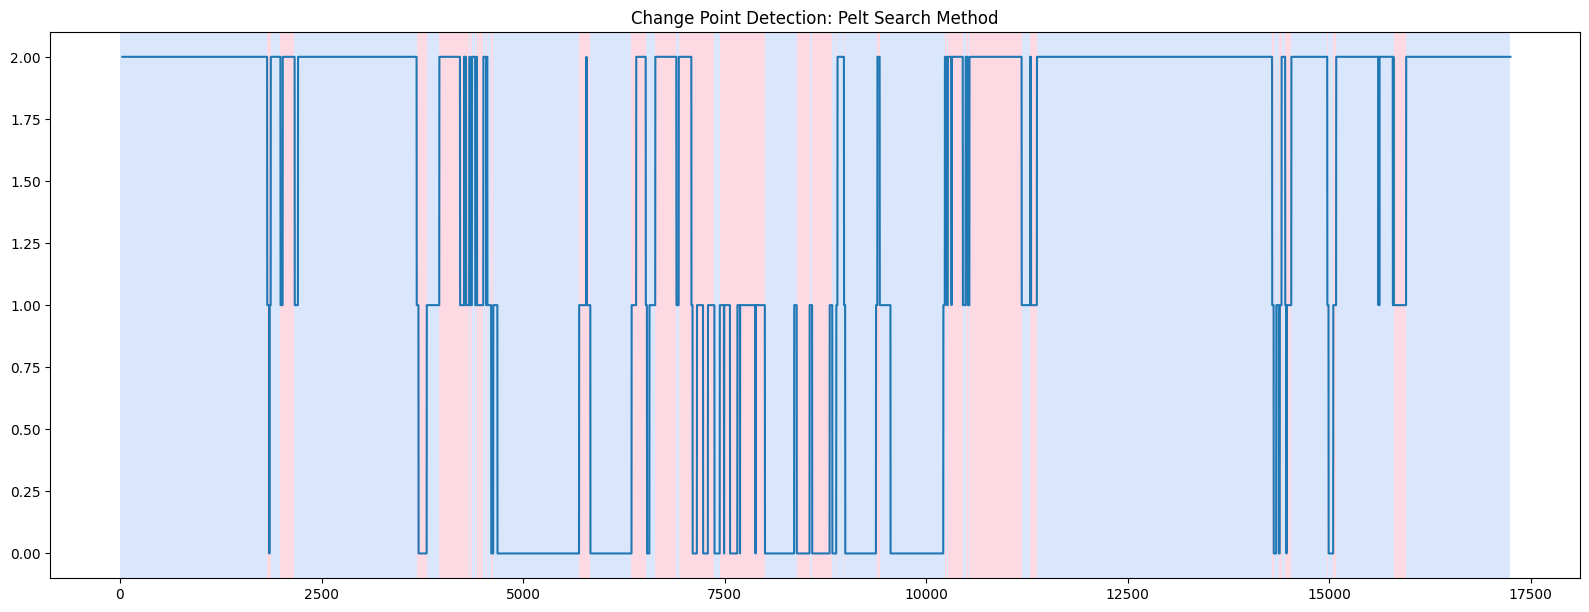

In [86]:
signal = df_total.iloc[:,49:50].values

algo = rpt.Window(model="l2", width=10).fit(signal)
result = algo.predict(n_bkps=60)

rpt.display(signal, result, figsize=(16, 6))
plt.title('Change Point Detection: Pelt Search Method')
plt.show()

result.insert(0, 0)

### Generating the event by start and end epoch_times

In [87]:
temp_start = 0
temp_end = result[0]

stress = []
for i in range (len(result)-1):
    
    temp = df_total.iloc[result[i]:(result[i+1]-1), 49:50].mean()[0]
    
    if temp > 1.3:
        temp = 2.0
    elif temp >= .65:
        temp = 1
    else:
        temp = 0

    stress.append(temp)
    
df_temp = pd.DataFrame(columns=['start', 'end', 'stress'])
c = 0
for i in range(len(result)-1):
    stressLength = (result[i+1] - result[i]) / 12

    start_point  = result[i]
    end_point    = result[i + 1]
    stress_value = stress[i]
    
    if temp_end <= start_point:
        temp_end       = end_point
        df_temp.loc[c] = [start_point, end_point, stress_value]
        c = c +1

df_temp

/tmp/ipykernel_168061/2647975276.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  temp = df_total.iloc[result[i]:(result[i+1]-1), 49:50].mean()[0]


,start,end,stress
0,0.0,1825.0,2.0
1,1825.0,1870.0,1.0
2,1870.0,1990.0,2.0
3,1990.0,2165.0,2.0
4,2165.0,3680.0,2.0
...,...,...,...
56,14990.0,15050.0,0.0
57,15050.0,15085.0,1.0
58,15085.0,15800.0,2.0
59,15800.0,15955.0,1.0


## Change event time to datetime

In [88]:
import pytz

stress_start = 0
stress_end = 0
tse = 0
previous_stress = -1

for index, row in df_temp.iterrows():

    if row['stress'] == previous_stress:
        stress_end = row['end']
    else:
        if(previous_stress != -1):
            start    = datetime.fromtimestamp(reference_time + (stress_start * 5),  pytz.timezone('Asia/Jerusalem'))
            end      = datetime.fromtimestamp(reference_time + (stress_end * 5), pytz.timezone('Asia/Jerusalem'))
            timediff = end - start
            print('Prev:', timediff, start, end, previous_stress)
        
        stress_start    = row['start']
        stress_end      = row['end']
        previous_stress = row['stress']
        
# print('Final:', timediff, datetime.fromtimestamp(reference_time + (stress_start * 5)).strftime('%H:%M:%S'), datetime.fromtimestamp(reference_time + (stress_end * 5)).strftime('%H:%M:%S'), previous_stress)
print('Final:', timediff, start, end, previous_stress)

Prev: 2:32:05 2025-04-03 00:20:33.500000+03:00 2025-04-03 02:52:38.500000+03:00 2.0
Prev: 0:03:45 2025-04-03 02:52:38.500000+03:00 2025-04-03 02:56:23.500000+03:00 1.0
Prev: 2:30:50 2025-04-03 02:56:23.500000+03:00 2025-04-03 05:27:13.500000+03:00 2.0
Prev: 0:10:25 2025-04-03 05:27:13.500000+03:00 2025-04-03 05:37:38.500000+03:00 0.0
Prev: 0:12:55 2025-04-03 05:37:38.500000+03:00 2025-04-03 05:50:33.500000+03:00 1.0
Prev: 0:32:05 2025-04-03 05:50:33.500000+03:00 2025-04-03 06:22:38.500000+03:00 2.0
Prev: 0:01:40 2025-04-03 06:22:38.500000+03:00 2025-04-03 06:24:18.500000+03:00 1.0
Prev: 0:03:20 2025-04-03 06:24:18.500000+03:00 2025-04-03 06:27:38.500000+03:00 2.0
Prev: 0:01:15 2025-04-03 06:27:38.500000+03:00 2025-04-03 06:28:53.500000+03:00 1.0
Prev: 0:00:50 2025-04-03 06:28:53.500000+03:00 2025-04-03 06:29:43.500000+03:00 2.0
Prev: 0:06:15 2025-04-03 06:29:43.500000+03:00 2025-04-03 06:35:58.500000+03:00 1.0
Prev: 0:02:55 2025-04-03 06:35:58.500000+03:00 2025-04-03 06:38:53.500000+03